### Scales & appearance
Edit the numbers marked `👈` and re-run.

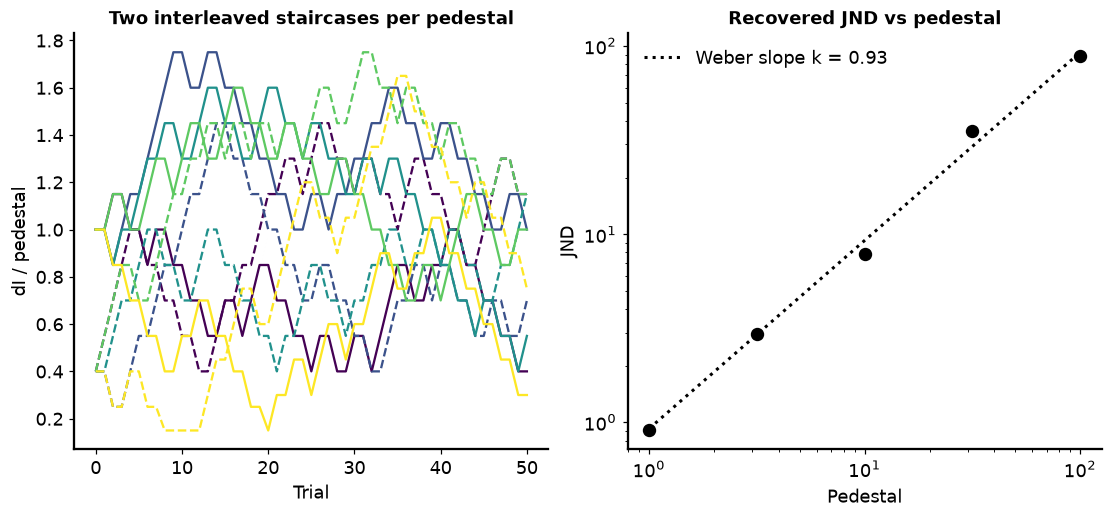

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

# Measuring the JND with an adaptive 2-down-1-up staircase (instead of full
# psychometric functions). Two interleaved staircases per pedestal.
rng = np.random.default_rng()
pedestals = np.logspace(0, 2, 5)
noise     = 1.0     # 👈 perceptual noise
n_trials  = 50      # 👈 trials per staircase (try fewer/more)

def run_staircase(ped, start, step, n):
    delta, run, traj = start, 0, [start]
    for _ in range(n):
        ref  = np.log(ped)         + rng.normal(0, noise)
        test = np.log(ped + delta) + rng.normal(0, noise)
        if test > ref:                       # correct
            run += 1
            if run == 2:                     # two in a row -> make it harder
                delta = max(delta - step, step); run = 0
        else:                                # wrong -> make it easier
            delta = delta + step; run = 0
        traj.append(delta)
    return np.array(traj)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.6), constrained_layout=True)
colours = plt.cm.viridis(np.linspace(0, 1, pedestals.size))
jnds = []
for pi, ped in enumerate(pedestals):
    step = ped * 0.15
    s1 = run_staircase(ped, ped * 1.0, step, n_trials)   # start above threshold
    s2 = run_staircase(ped, ped * 0.4, step, n_trials)   # start below threshold
    axL.plot(s1 / ped, color=colours[pi], lw=1.5)
    axL.plot(s2 / ped, color=colours[pi], lw=1.5, ls="--")
    jnds.append((s1[-12:].mean() + s2[-12:].mean()) / 2)
axL.set(xlabel="Trial", ylabel="dI / pedestal",
        title="Two interleaved staircases per pedestal")

jnds = np.array(jnds)
axR.scatter(pedestals, jnds, 60, color="k", zorder=3)
weber = np.mean(jnds / pedestals)
axR.plot(pedestals, pedestals * weber, "k:", lw=2, label=f"Weber slope k = {weber:.2f}")
axR.set(xscale="log", yscale="log", xlabel="Pedestal", ylabel="JND",
        title="Recovered JND vs pedestal")
axR.legend()
plt.show()
